In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import random

from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.utils import plot_model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder

SEED_VALUE = 42
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)

ModuleNotFoundError: No module named 'pandas'

# Load Data and Preparation

In [2]:
df = pd.read_csv("./credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [4]:
df.dropna(inplace=True)

In [5]:
df.duplicated().sum()

137

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
num_cols = []
cat_cols = []

for col in df.columns :
    if df[col].dtype == 'object' :
        cat_cols.append(col)
    else : 
        num_cols.append(col)

print(num_cols)
print(cat_cols)

['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


In [8]:
ord_cols = ['loan_grade']
nom_cols = ['person_home_ownership', 'loan_intent']
bin_cols = ['cb_person_default_on_file']

# Split Data

In [16]:
x, y = df.drop(columns=['loan_amnt'], axis=1), df['loan_amnt']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=SEED_VALUE)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.25, random_state=SEED_VALUE)
print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(22800, 11) (22800,)
(4275, 11) (4275,)
(1426, 11) (1426,)


# Data Preproccessing

In [17]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
new_nom_cols = ohe.fit_transform(x_train[nom_cols])
encoded = pd.DataFrame(new_nom_cols, columns=ohe.get_feature_names_out(nom_cols))
x_train.reset_index(drop=True)
x_train = pd.concat([x_train.drop(nom_cols, axis=1, errors='ignore'), encoded], axis=1)

In [18]:
#x_train.dropna(inplace=True)
x_train

,person_age,person_income,person_emp_length,loan_grade,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
30943,41.0,70000.0,12.0,B,12.21,0.0,0.30,N,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23888,27.0,61000.0,6.0,D,15.99,1.0,0.11,N,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6512,22.0,45000.0,0.0,C,13.23,0.0,0.13,N,4.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
6054,25.0,48000.0,6.0,A,6.99,0.0,0.07,N,2.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3517,22.0,41900.0,3.0,A,8.49,0.0,0.25,N,2.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
22794,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
22796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
22797,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [19]:
x_train.drop(ord_cols, errors='ignore', inplace=True, axis=1)
x_train.drop(bin_cols, errors='ignore', inplace=True, axis=1)

In [20]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(32)

ValueError: Dimensions 29662 and 22800 are not compatible

# Create Model

## Sequential

In [15]:
model = tf.keras.Sequential([
    Dense(9, activation='relu', input_shape=(11,)),
    Dense(3, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [16]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 5)                 60        
                                                                 
 dense_1 (Dense)             (None, 3)                 18        
                                                                 
 dense_2 (Dense)             (None, 1)                 4         
                                                                 
Total params: 82 (328.00 Byte)
Trainable params: 82 (328.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [19]:
x = tf.constant([[i for i in range(11)]])

In [20]:
model.predict(x)

2024-02-24 09:10:01.926820: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


1/1 [==============================] - 1s 1s/step


array([[3.4877787]], dtype=float32)

## Functional

In [2]:
inputs = tf.keras.Input(shape=(11,))
dense1 = Dense(24, activation='relu')(inputs)
dense2 = Dense(12, activation=tf.keras.layers.LeakyReLU(alpha=0.2))(dense1)
cat_layer = tf.keras.layers.Concatenate(axis=1)([dense1, dense2])
out = Dense(1, activation='sigmoid')(cat_layer)

model = Model(inputs=inputs, outputs=out)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 11)]                 0         []                            
                                                                                                  
 dense (Dense)               (None, 24)                   288       ['input_1[0][0]']             
                                                                                                  
 dense_1 (Dense)             (None, 12)                   300       ['dense[0][0]']               
                                                                                                  
 concatenate (Concatenate)   (None, 36)                   0         ['dense[0][0]',               
                                                                     'dense_1[0][0]']         

2024-03-02 08:54:32.564452: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-02 08:54:32.626722: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-02 08:54:32.626822: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-02 08:54:32.631241: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-02 08:54:32.631572: I external/local_xla/xla/stream_executor

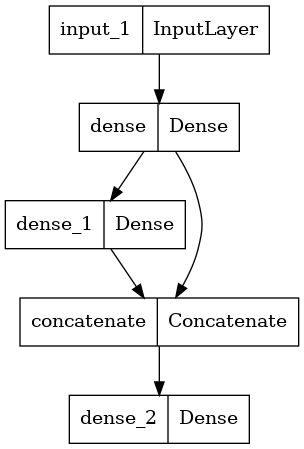

In [3]:
plot_model(model)